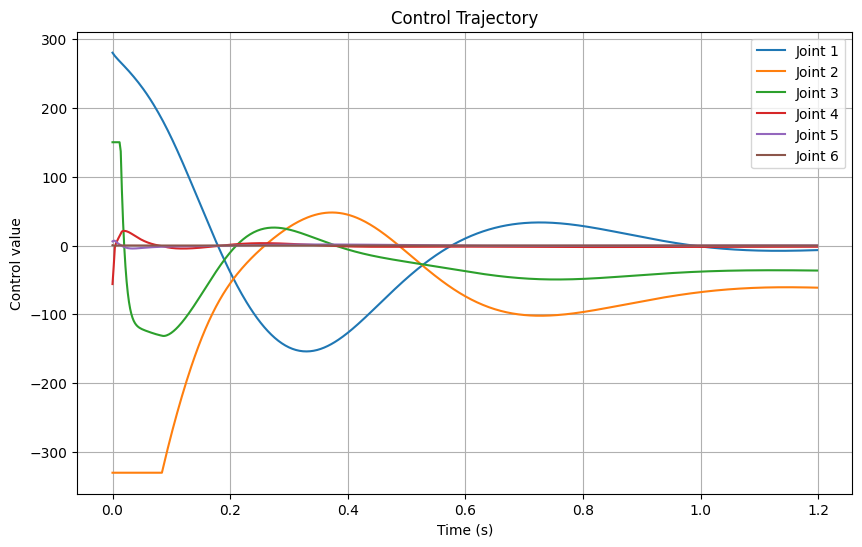

In [4]:
from optimal.PDController import PDController
from optimal.Visualizer import Visualizer
import pinocchio as pin
import numpy as np
import mujoco

mjcf_path = "../models/ur10/ur10.xml"
urdf_path = "../models/ur10/ur10.urdf"
robot_mj_model = mujoco.MjModel.from_xml_path(mjcf_path)
robot_pin_model = pin.buildModelFromUrdf(urdf_path)

kp = np.array([400.0, 800.0, 400.0, 100.0, 4.0, 1.0])
kd = np.array([40.0,  80.0,  40.0,  10.0,  .4,  .1])
pd_controller = PDController(robot_pin_model, kp=kp, kd=kd)

DT = robot_mj_model.opt.timestep
q_start = pin.neutral(robot_pin_model)
q_target = np.array([0.7, -1.2, 1.5, -0.8, 1.5, 0.5])
xs, us = pd_controller.compute_control(x_start=q_start, x_goal=q_target, horizon=600, control_dt=DT)

robot_mj_data = mujoco.MjData(robot_mj_model)
viewer = Visualizer(robot_mj_model, robot_mj_data)
viewer.plot_controls(us, dt=DT)

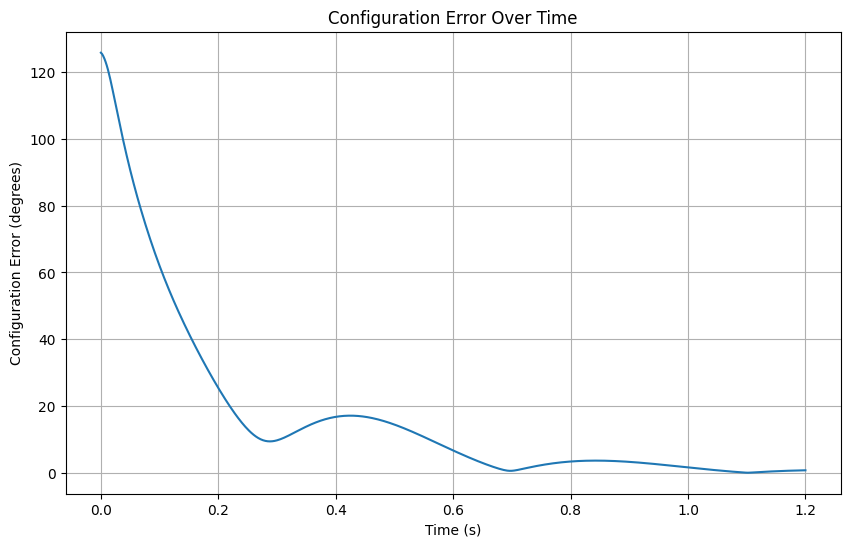

In [5]:
x_pos = viewer.visualize(mode="position", vector=xs, dt=DT, hold=False)
viewer.plot_error(x_pos, q_target, dt=DT)


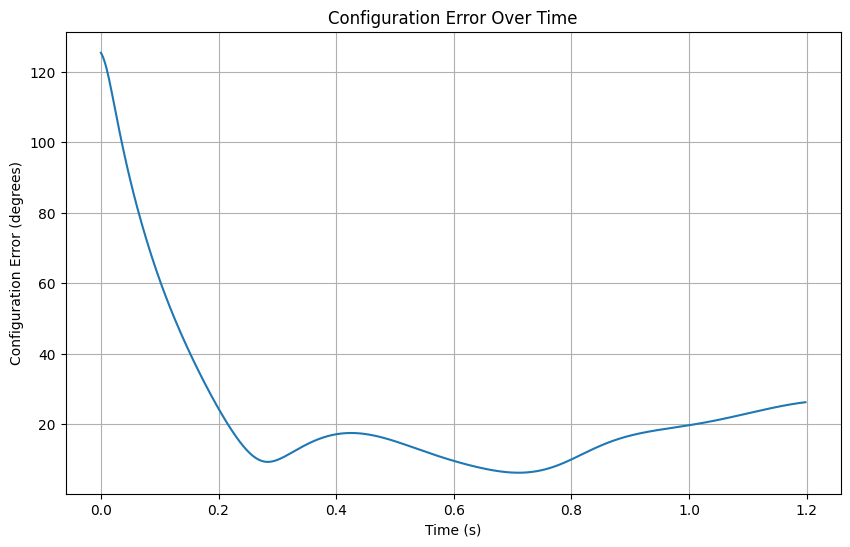

In [6]:
robot_mj_data.qpos[:] = q_start
robot_mj_data.qvel[:] = 0.0
mujoco.mj_forward(robot_mj_model, robot_mj_data)
x_pos = viewer.visualize(mode="control", vector=us, dt=DT, hold=False)
viewer.plot_error(x_pos, q_target, dt=DT)

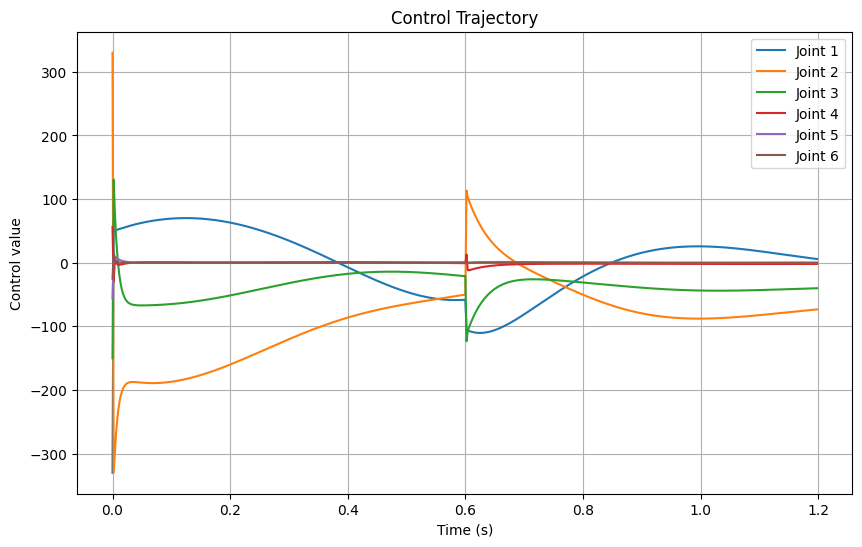

In [11]:
xs, us = pd_controller.compute_control(x_start=q_start, x_goal=q_target, horizon=600, control_dt=DT, alpha=0.5)
viewer.plot_controls(us, dt=DT)


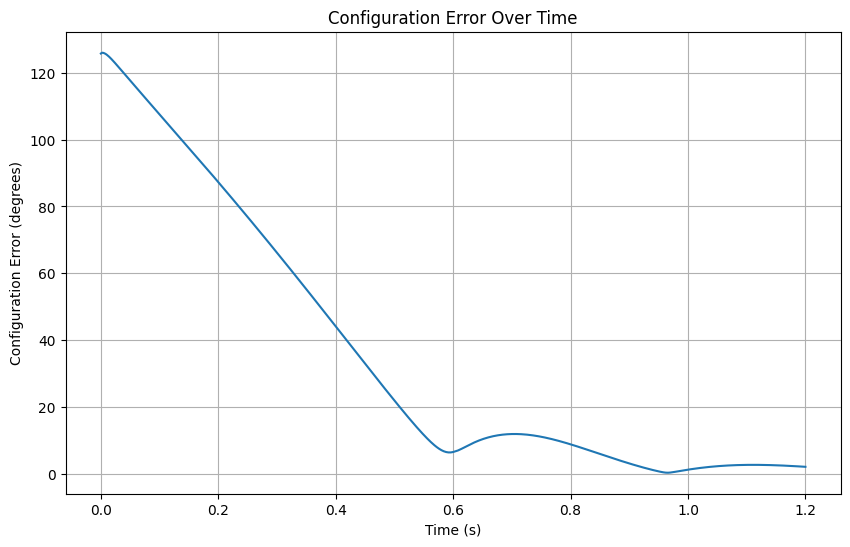

In [13]:
x_pos = viewer.visualize(mode="position", vector=xs, dt=DT, hold=False)
viewer.plot_error(x_pos, q_target, dt=DT)


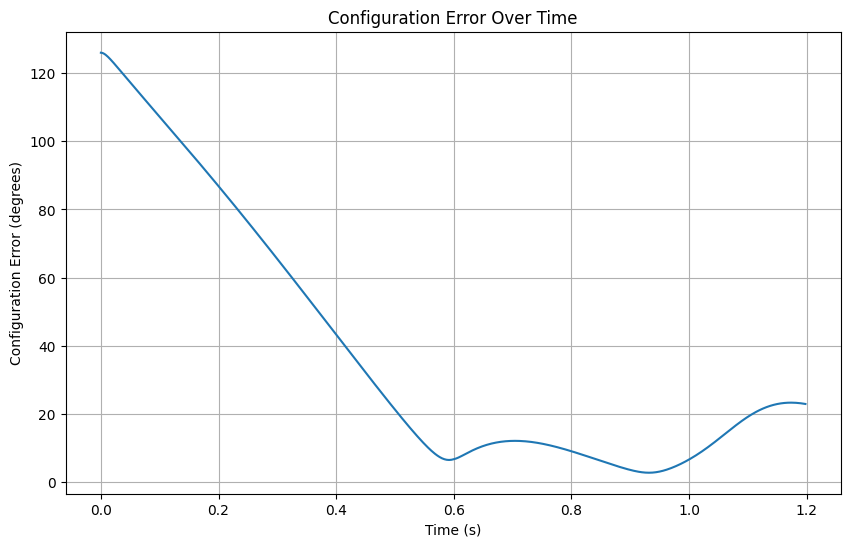

In [12]:
robot_mj_data.qpos[:] = q_start
robot_mj_data.qvel[:] = 0.0
mujoco.mj_forward(robot_mj_model, robot_mj_data)
x_pos = viewer.visualize(mode="control", vector=us, dt=DT, hold=False)
viewer.plot_error(x_pos, q_target, dt=DT)
